## Experiment Analysis: Number of Superpixels

This notebook analyzes the results obtained as the number of superpixels varies for the dataset in question. Each image used in the construction of the convolutional filters presents the same number of superpixels using the technique presented in iftDISF.

In [1]:
# Library imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
from collections import Counter
from collections import defaultdict
from scipy.stats import wilcoxon
from scipy import stats

# Visualization settings
plt.rcParams['figure.figsize'] = (12, 8)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Display the dataframe to fit nicely on the screen
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)

#### 1. Data Loading, Processing and Save

Loading the experiment-generated files and converting them into a structured DataFrame for analysis.

In [2]:
# Path to the experiments directory
dir_experiments = "../experiments/nsuperpixels/results"

# Dicionários separados
results_files = defaultdict(dict)
superpixel_images = defaultdict(dict)

# Traverse the experiments directory
for superpixel_folder in sorted(os.listdir(dir_experiments)):
    superpixel_path = os.path.join(dir_experiments, superpixel_folder)
    if os.path.isdir(superpixel_path) and superpixel_folder.startswith("super"):
        # Armazena arquivos de resultados
        for file in sorted(os.listdir(superpixel_path)):
            if file.endswith("_results.csv") or file.endswith("_layer3_test1-classified-images.cvs"):
                results_files[superpixel_folder][file] = os.path.join(superpixel_path, file)
        # Armazena imagens dos superpixels
        for seed_folder in sorted(os.listdir(superpixel_path)):
            seed_path = os.path.join(superpixel_path, seed_folder)
            if os.path.isdir(seed_path) and seed_folder.startswith("superpixels_seed"):
                superpixel_images[superpixel_folder][seed_folder] = []
                for img_file in sorted(os.listdir(seed_path)):
                    superpixel_images[superpixel_folder][seed_folder].append(os.path.join(seed_path, img_file))
                    
# Create a structured DataFrame to store the results
results_data = []
superpixels_values = []

for superpixel, contents in results_files.items():
    superpixels_values.append(int(superpixel.replace('super', '')))
    for seed, files in contents.items():
        if isinstance(files, str) and files.endswith('_results.csv'):
            results_file = files
            seed_value = int(seed.replace('_results.csv', '').replace('seed', ''))
            with open(results_file, 'r') as f:
                lines = f.readlines()
                if len(lines) >= 4:
                    class_accuracies = list(map(float, lines[0].strip().split(';')[:9]))
                    class1_accuracy, class2_accuracy = class_accuracies[0], class_accuracies[1]
                    class3_accuracy, class4_accuracy = class_accuracies[2], class_accuracies[3]
                    class5_accuracy, class6_accuracy = class_accuracies[4], class_accuracies[5]
                    class7_accuracy, class8_accuracy = class_accuracies[6], class_accuracies[7]
                    class9_accuracy = class_accuracies[8]
                    kappa, global_accuracy = map(float, lines[1].strip().split(';')[:2])
                    nfeat = int(lines[3].strip().split(': ')[1])
                    results_data.append({
                    'superpixel': int(superpixel.replace('super', '')),
                    'seed': seed_value,
                    'class1_accuracy': class1_accuracy,
                    'class2_accuracy': class2_accuracy,
                    'class3_accuracy': class3_accuracy,
                    'class4_accuracy': class4_accuracy,
                    'class5_accuracy': class5_accuracy,
                    'class6_accuracy': class6_accuracy,
                    'class7_accuracy': class7_accuracy,
                    'class8_accuracy': class8_accuracy,
                    'class9_accuracy': class9_accuracy,
                    'kappa': kappa,
                    'global_accuracy': global_accuracy,
                    'nfeat': nfeat
                    })


# Convert the results data into a DataFrame
df_nsuper = pd.DataFrame(results_data) 

# Save the DataFrame to a CSV file
df_nsuper.to_csv('nsuperpixels_results_summary.csv', index=False)

#### 2. Analyses and Visualization

In [3]:
# Group by number of superpixels and calculate mean and std for each class accuracy
class_metrics = [f'class{i}_accuracy' for i in range(1, 10)]
class_metrics.extend(['kappa', 'global_accuracy'])
class_stats = df_nsuper.groupby('superpixel')[class_metrics].agg(['mean', 'std']).reset_index()

# Rename columns for easier access (e.g., 'class1_accuracy_mean')
class_stats.columns = ['_'.join(col).strip() for col in class_stats.columns.values]

# Arrange the DataFrame according to the order of superpixel values
class_stats = class_stats.set_index('superpixel_').loc[sorted(superpixels_values)].reset_index()
class_stats

latex_table = class_stats.to_latex(float_format="%.6f")
print(latex_table)

# Highlight the highest mean accuracy for each class
# highlight_cols = [f'{c}_mean' for c in class_metrics]
# class_stats_styled = class_stats.style.highlight_max(subset=highlight_cols, color='gray')

# # Format values as percentages for better presentation
# format_dict = {col: '{:.4%}' for col in highlight_cols}
# class_stats_styled = class_stats_styled.format(format_dict)

# Display the styled DataFrame
# class_stats_styled

# latex table
# latex_table = df_nsuper.groupby('superpixel')[metrics[:-1]].agg(['mean', 'std']).loc[superpixels_values].to_latex(float_format="%.6f")
# print(latex_table)

\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & superpixel_ & class1_accuracy_mean & class1_accuracy_std & class2_accuracy_mean & class2_accuracy_std & class3_accuracy_mean & class3_accuracy_std & class4_accuracy_mean & class4_accuracy_std & class5_accuracy_mean & class5_accuracy_std & class6_accuracy_mean & class6_accuracy_std & class7_accuracy_mean & class7_accuracy_std & class8_accuracy_mean & class8_accuracy_std & class9_accuracy_mean & class9_accuracy_std & kappa_mean & kappa_std & global_accuracy_mean & global_accuracy_std \\
\midrule
0 & 15 & 0.937931 & 0.022472 & 0.952500 & 0.018447 & 0.789189 & 0.038854 & 0.926229 & 0.015931 & 0.931953 & 0.020355 & 0.978723 & 0.005015 & 0.913115 & 0.026826 & 0.959322 & 0.013129 & 0.954306 & 0.007545 & 0.905711 & 0.013034 & 0.947282 & 0.007406 \\
1 & 25 & 0.943104 & 0.022085 & 0.957500 & 0.020582 & 0.816216 & 0.038854 & 0.939344 & 0.031910 & 0.935503 & 0.016608 & 0.978191 & 0.004658 & 0.926230 & 0.017707 & 0.949152 & 0.009786 & 0.956220 &

In [4]:
# Define the metrics to be analyzed (excluding 'nfeat' for summary statistics)
metrics = ['class1_accuracy', 'class2_accuracy', 'class3_accuracy', 'class4_accuracy', 'class5_accuracy', 'class6_accuracy', 'class7_accuracy', 'class8_accuracy', 'class9_accuracy', 'kappa', 'global_accuracy', 'nfeat']

# Group results by number of superpixels and calculate mean and standard deviation for each metric
summary_stats = df_nsuper.groupby('superpixel')[metrics[:-1]].agg(['mean', 'std']).reset_index()

# Rename columns for easier access (e.g., 'kappa_mean', 'global_accuracy_mean')
summary_stats.columns = ['_'.join(col).strip() for col in summary_stats.columns.values]

# Arrange the DataFrame according to the order of superpixel values
superpixels_values = sorted(superpixels_values)
summary_stats = summary_stats.set_index('superpixel_').loc[superpixels_values].reset_index()

# Select only the metrics of interest for visualization and highlight the highest values
summary_stats = summary_stats[['superpixel_', 'class1_accuracy_mean',  'kappa_mean', 'kappa_std', 'global_accuracy_mean', 'global_accuracy_std']].style.highlight_max(
    subset=['kappa_mean', 'global_accuracy_mean'], color='gray'
)

# # Format values as percentages for better presentation
# summary_stats = summary_stats.format({'kappa_mean': '{:.4%}', 'global_accuracy_mean': '{:.4%}'})

# Display the styled DataFrame
summary_stats

,superpixel_,class1_accuracy_mean,kappa_mean,kappa_std,global_accuracy_mean,global_accuracy_std
0,15,0.937931,0.905711,0.013034,0.947282,0.007406
1,25,0.943104,0.910777,0.010443,0.950098,0.005966
2,50,0.943104,0.913634,0.007304,0.951819,0.004219
3,75,0.944828,0.913136,0.012529,0.951467,0.007091
4,100,0.944253,0.909940,0.008925,0.949707,0.005033
5,150,0.945977,0.908532,0.010971,0.948885,0.006192
6,200,0.943678,0.907802,0.010235,0.948416,0.005820


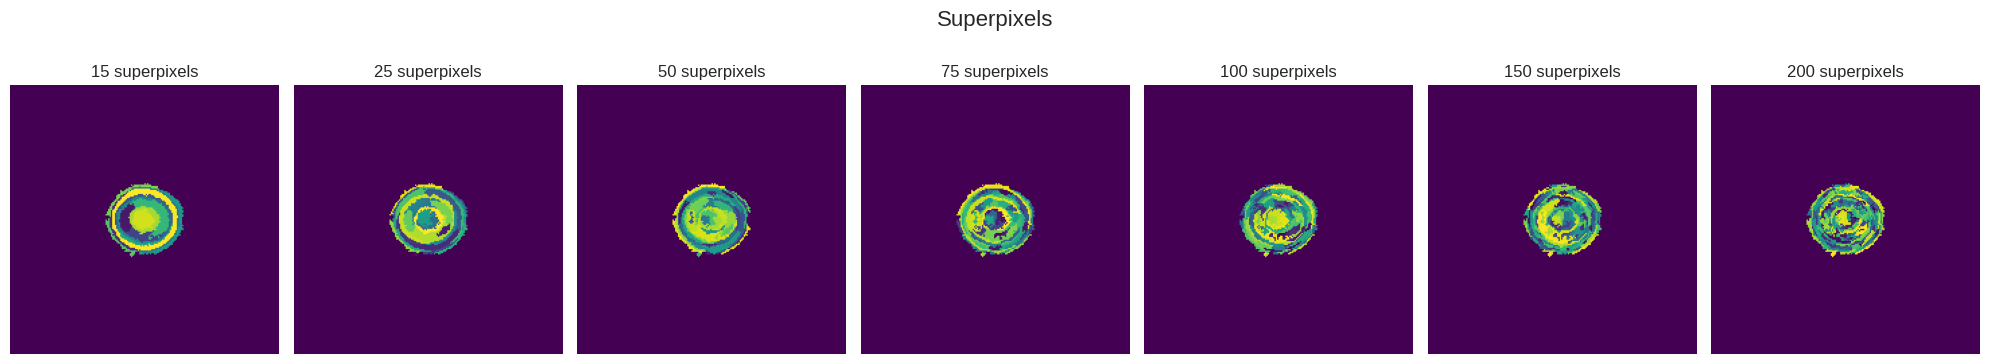

In [5]:
# Sort the superpixel values for consistent visualization order
ordered_superpixels = sorted(superpixels_values)
fig, axes = plt.subplots(1, len(ordered_superpixels), figsize=(20, 4))
fig.suptitle('Superpixels', fontsize=16)
seed = 42
class_idx = 2

# Para cada valor de superpixel, exibe a primeira imagem correspondente à class_idx para a seed selecionada
for i, superpixel in enumerate(ordered_superpixels):
    img_files = superpixel_images[f'super{superpixel}'][f'superpixels_seed{seed}']
    # As imagens estão nomeadas como '000001_...', '000002_...', ..., '000009_...'
    # class_idx corresponde ao número da classe (1 a 9)
    class_img_name = f'{class_idx:06d}_'
    # Busca a primeira imagem que corresponde à class_idx
    img_path = next((img for img in img_files if os.path.basename(img).startswith(class_img_name)), None)
    if img_path:
        img = plt.imread(img_path)
        axes[i].imshow(img.squeeze(), cmap='viridis')
        axes[i].set_title(f'{superpixel} superpixels')
        axes[i].axis('off')

plt.tight_layout()
plt.show()


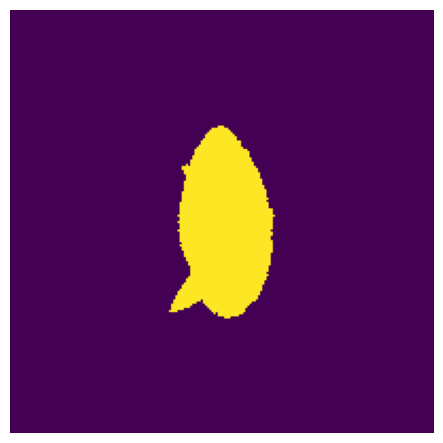

In [13]:
# mostrar uma imagem dado o caminho
def show_image(image_path):
    img = plt.imread(image_path)
    plt.imshow(img.squeeze(), cmap='viridis')
    plt.axis('off')
    plt.show()

img_path = '../build/masks/000007_00000034.png'
show_image(img_path)

In [16]:
# Mode of the number of features per superpixel
nfeat_mode = df_nsuper.groupby('superpixel')['nfeat'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
nfeat_mode = nfeat_mode.sort_values()
# Display the mode of number of features per superpixel as a table
display(nfeat_mode.to_frame().rename(columns={'nfeat': 'Mode of nfeat'}))


,Mode of nfeat
superpixel,
15,14520
25,24200
50,48400
75,72600
100,96800
150,145200
200,193600


In [17]:
# Perform Wilcoxon signed-rank test for all pairs of superpixel values
wilcoxon_results = pd.DataFrame(columns=['superpixel1', 'superpixel2', 'statistic', 'p_value'])

for i in range(len(ordered_superpixels)):
    for j in range(i + 1, len(ordered_superpixels)):
        sp1 = ordered_superpixels[i]
        sp2 = ordered_superpixels[j]
        
        data_sp1 = df_nsuper[df_nsuper['superpixel'] == sp1]['global_accuracy']
        data_sp2 = df_nsuper[df_nsuper['superpixel'] == sp2]['global_accuracy']
        
        # Only perform the test if sample sizes are equal and greater than 0
        if len(data_sp1) > 0 and len(data_sp2) > 0 and len(data_sp1) == len(data_sp2):
            statistic, p_value = wilcoxon(data_sp1, data_sp2)
            wilcoxon_results.loc[len(wilcoxon_results)] = {
                'superpixel1': sp1,
                'superpixel2': sp2,
                'statistic': statistic,
                'p_value': p_value
            }

print("Wilcoxon test results:")
print(wilcoxon_results)

significant = wilcoxon_results[wilcoxon_results['p_value'] < 0.05]
print("Comparisons with statistically significant difference:")
print(significant)
print(f"Total significant comparisons: {len(significant)} out of {len(wilcoxon_results)}")


Wilcoxon test results:
    superpixel1  superpixel2  statistic   p_value
0            15           25       16.0  0.275391
1            15           50        9.0  0.128906
2            15           75        9.0  0.062500
3            15          100       13.0  0.150391
4            15          150       20.5  0.507812
5            15          200       23.0  0.695312
6            25           50       16.0  0.275391
7            25           75       16.5  0.515625
8            25          100       24.5  0.791016
9            25          150       13.0  0.300781
10           25          200        6.0  0.109375
11           50           75       26.0  0.900391
12           50          100       13.5  0.169922
13           50          150       10.5  0.085938
14           50          200       12.0  0.126953
15           75          100       13.0  0.154297
16           75          150       16.0  0.275391
17           75          200        3.0  0.078125
18          100          15

In [18]:
# Path to the experiments directory
dir_experiments = "../experiments/nsuperpixels/results"

# Dicionários separados
results_files_pred = defaultdict(dict)
superpixel_images = defaultdict(dict)

# Traverse the experiments directory
for superpixel_folder in sorted(os.listdir(dir_experiments)):
    superpixel_path = os.path.join(dir_experiments, superpixel_folder)
    if os.path.isdir(superpixel_path) and superpixel_folder.startswith("super"):
        # Armazena arquivos de resultados
        for file in sorted(os.listdir(superpixel_path)):
            if file.endswith("layer3_test1-classified-images.csv"):
                seed = int(file.split('_')[0].replace('seed', ''))
                superpixel = int(superpixel_folder.replace('super', ''))
                with open(os.path.join(superpixel_path, file), 'r') as f:
                    lines = f.readlines()
                    correct_class = []
                    predicted_class = []
                    img_name = []
                    for line in lines:
                        parts = line.strip().split(';')
                        if len(parts) >= 2:
                            img_name.append(parts[0])
                            correct_class.append(int(parts[1]))
                            predicted_class.append(int(parts[2]))
                results_files_pred[superpixel][seed] = {'img_name': img_name, 'correct': correct_class, 'predicted': predicted_class}

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# montar matriz de confusão para cada superpixel e semente
confusion_matrices = {}
for superpixel, seeds_data in results_files_pred.items():
    confusion_matrices[superpixel] = {}
    for seed, data in seeds_data.items():
        correct = np.array(data['correct'])
        # qtd de amostras por classe
        unique, counts = np.unique(correct, return_counts=True)
        class_distribution = dict(zip(unique, counts))
        # print(f"Superpixel: {superpixel}, Seed: {seed}, Class distribution: {class_distribution}")
        predicted = np.array(data['predicted'])
        # Create confusion matrix
        cm = pd.crosstab(correct, predicted, rownames=['Actual'], colnames=['Predicted'], dropna=False)
        confusion_matrices[superpixel][seed] = cm
        
# Example: Display confusion matrix for superpixel=100 and seed=42
# superpixel_to_display = 100
# seed_to_display = 42
# if superpixel_to_display in confusion_matrices and seed_to_display in confusion_matrices[superpixel_to_display]:
#     cm = confusion_matrices[superpixel_to_display][seed_to_display]
#     print(f"Confusion Matrix for Superpixel={superpixel_to_display}, Seed={seed_to_display}:\n{cm}")

evaluation_metrics = []
for superpixel, seeds_data in results_files_pred.items():
    for seed, data in seeds_data.items():
        y_true = data['correct']
        y_pred = data['predicted']
        cm = confusion_matrix(y_true, y_pred, labels=[1, 2])
        tn, fp, fn, tp = cm.ravel()
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average='macro')
        recall = recall_score(y_true, y_pred, average='macro')
        f1 = f1_score(y_true, y_pred, average='macro')
        evaluation_metrics.append({
            "superpixel": superpixel,
            "seed": seed,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })
        
df_metrics = pd.DataFrame(evaluation_metrics)
# media para cada superpixel
df_metrics_mean = df_metrics.groupby('superpixel').mean().reset_index()
df_metrics_mean

# mostrar codigo latex 
# df_metrics = pd.DataFrame(evaluation_metrics)
# df_metrics_mean = df_metrics.groupby('superpixel').mean().reset_index()
# df_metrics_mean
# latex_table = df_metrics_mean.to_latex(float_format="%.6f")
# print(latex_table)

,superpixel,seed,accuracy,precision,recall,f1
0,15,2970.3,0.947282,0.903843,0.927030,0.914475
1,25,2970.3,0.950098,0.907720,0.933496,0.919697
2,50,2970.3,0.951819,0.910719,0.931315,0.920115
3,75,2970.3,0.951467,0.908395,0.933639,0.920197
4,100,2970.3,0.949707,0.906718,0.929536,0.917166
5,150,2970.3,0.948885,0.904809,0.926896,0.915010
6,200,2970.3,0.948416,0.903173,0.928290,0.914944


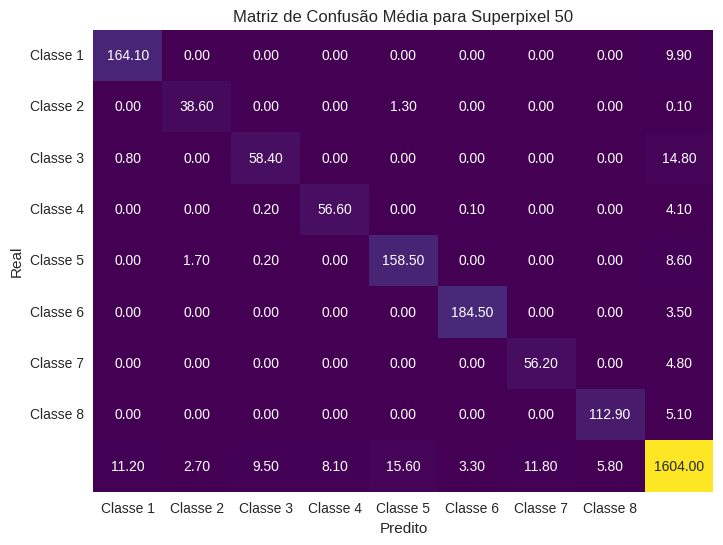

In [20]:
class_names = ['Classe 1', 'Classe 2', 'Classe 3', 'Classe 4', 'Classe 5', 'Classe 6', 'Classe 7', 'Classe 8']
superpixel_to_display = 50
if superpixel_to_display in confusion_matrices:
    cm_mean = sum(confusion_matrices[superpixel_to_display].values()) / len(confusion_matrices[superpixel_to_display])
    # Remove a última linha e coluna (assumindo que correspondem à classe 9/Impurezas)
    # cm_mean = cm_mean.iloc[:-1, :-1]
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_mean, annot=True, fmt=".2f", cmap="viridis",
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    plt.title(f"Matriz de Confusão Média para Superpixel {superpixel_to_display}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()